Random Forest

Dataset Description:

Use the Glass dataset and apply the Random forest model.

1. Exploratory Data Analysis (EDA):

Perform exploratory data analysis to understand the structure of the dataset.
Check for missing values, outliers, inconsistencies in the data.

2: Data Visualization:

Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.
Analyze any patterns or correlations observed in the data.

3: Data Preprocessing

1. Check for missing values in the dataset and decide on a strategy for handling them.Implement the chosen strategy (e.g., imputation or removal) and explain your reasoning.
2. If there are categorical variables, apply encoding techniques like one-hot encoding to convert them into numerical format.
3. Apply feature scaling techniques such as standardization or normalization to ensure that all features are on a similar scale. Handling the imbalance data.

4: Random Forest Model Implementation
1. Divide the data into train and test split.
2. Implement a Random Forest classifier using Python and a machine learning library like scikit-learn.
3. Train the model on the train dataset. Evaluate the performance on test data using metrics like accuracy, precision, recall, and F1-score.

5: Bagging and Boosting Methods
Apply the Bagging and Boosting methods and compare the results.


Additional Notes:
1. Explain Bagging and Boosting methods. How is it different from each other.
2. Explain how to handle imbalance in the data.

# Task
Analyze the Glass dataset from '/content/glass.xlsx' by performing exploratory data analysis, data visualization, and preprocessing. Implement and evaluate Random Forest, Bagging, and Boosting classification models, comparing their performance. Additionally, explain the principles of Bagging and Boosting methods and strategies for handling imbalanced datasets. Finally, summarize the findings from the analysis, preprocessing, and model comparisons.

## Load Dataset

Load the Glass dataset from '/content/glass.xlsx' into a pandas DataFrame and display its head and basic information.


To load the Excel dataset and display its initial rows and structure, I need to import the pandas library, read the Excel file, and then use the .head() and .info() methods.



In [8]:
import pandas as pd
xls = pd.ExcelFile('/content/glass.xlsx')
sheet_names = xls.sheet_names
print("Sheet names in glass.xlsx:", sheet_names)

Sheet names in glass.xlsx: ['Description', 'glass']


Since the `glass.xlsx` file contains a sheet named 'glass', we will now load the data from this specific sheet into a DataFrame and display its head and information to ensure the correct dataset is loaded.



In [9]:
import pandas as pd
df = pd.read_excel('/content/glass.xlsx', sheet_name='glass')

print("DataFrame Head (from 'glass' sheet):")
print(df.head())

print("\nDataFrame Info (from 'glass' sheet):")
df.info()

DataFrame Head (from 'glass' sheet):
        RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Type
0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0     1
1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0     1
2  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0     1
3  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0     1
4  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0     1

DataFrame Info (from 'glass' sheet):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-nu

## Exploratory Data Analysis (EDA)

Perform initial exploratory data analysis including checking data types, descriptive statistics, and identifying missing values and inconsistencies in the dataset.


To perform the initial exploratory data analysis, We will display the data types and non-null counts, generate descriptive statistics, and explicitly check for missing values in the DataFrame `df`.



In [ ]:
print("\nDataFrame Info (data types and non-null counts):\n")
df.info()

print("\nDescriptive Statistics:\n")
print(df.describe())

print("\nMissing Values Sum:\n")
print(df.isnull().sum())


DataFrame Info (data types and non-null counts):

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB

Descriptive Statistics:

               RI          Na          Mg          Al          Si           K  \
count  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000   
mean     1.518365   13.407850    2.684533    1.444907   72.650935    0.497056   
std      0.003037    0.816604    1.442408    0.499270    0.774546    0.652192   

The previous step successfully performed initial EDA, confirming data types, descriptive statistics, and the absence of missing values. Now, We will proceed with data visualization, as outlined in the overall task, starting with creating histograms for each numerical feature to visualize their distributions. This aligns with subtask 2: 'Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.'



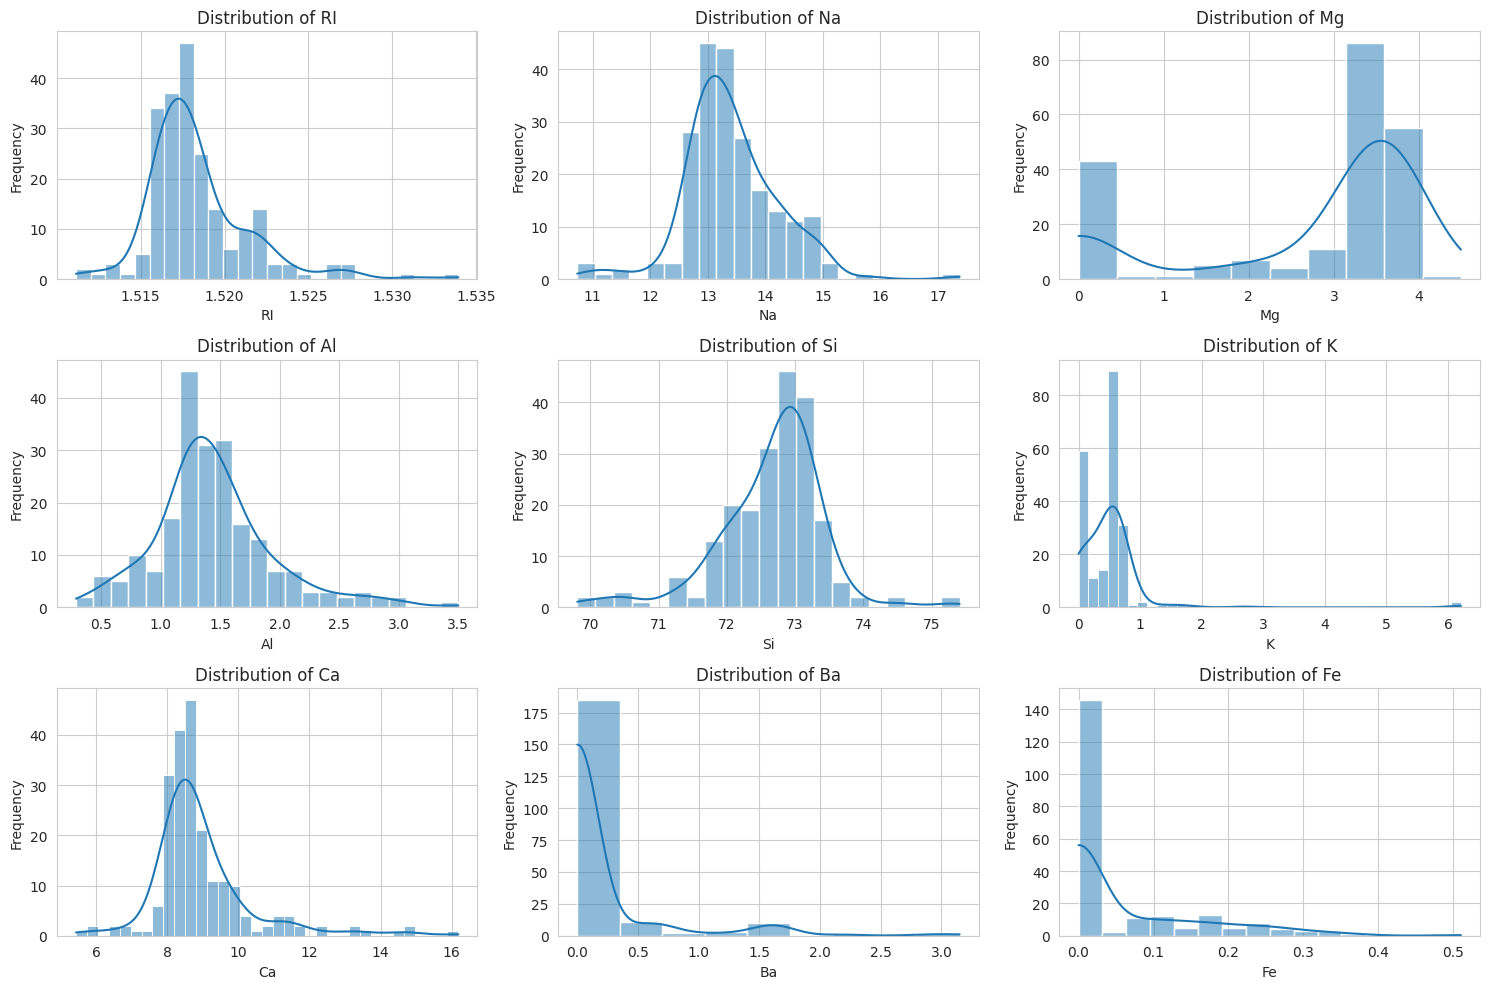

Histograms generated for all numerical features.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style("whitegrid")

# Get the list of numerical columns (excluding 'Type' as it's the target variable)
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop('Type')

# Create histograms for numerical features
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of features
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("Histograms generated for all numerical features.")

Following the creation of histograms, the next step in data visualization is to generate box plots for each numerical feature. This will help identify outliers and visualize the spread and skewness of the data, which is crucial for understanding the dataset's structure and potential inconsistencies, aligning with subtask 2 of the EDA.



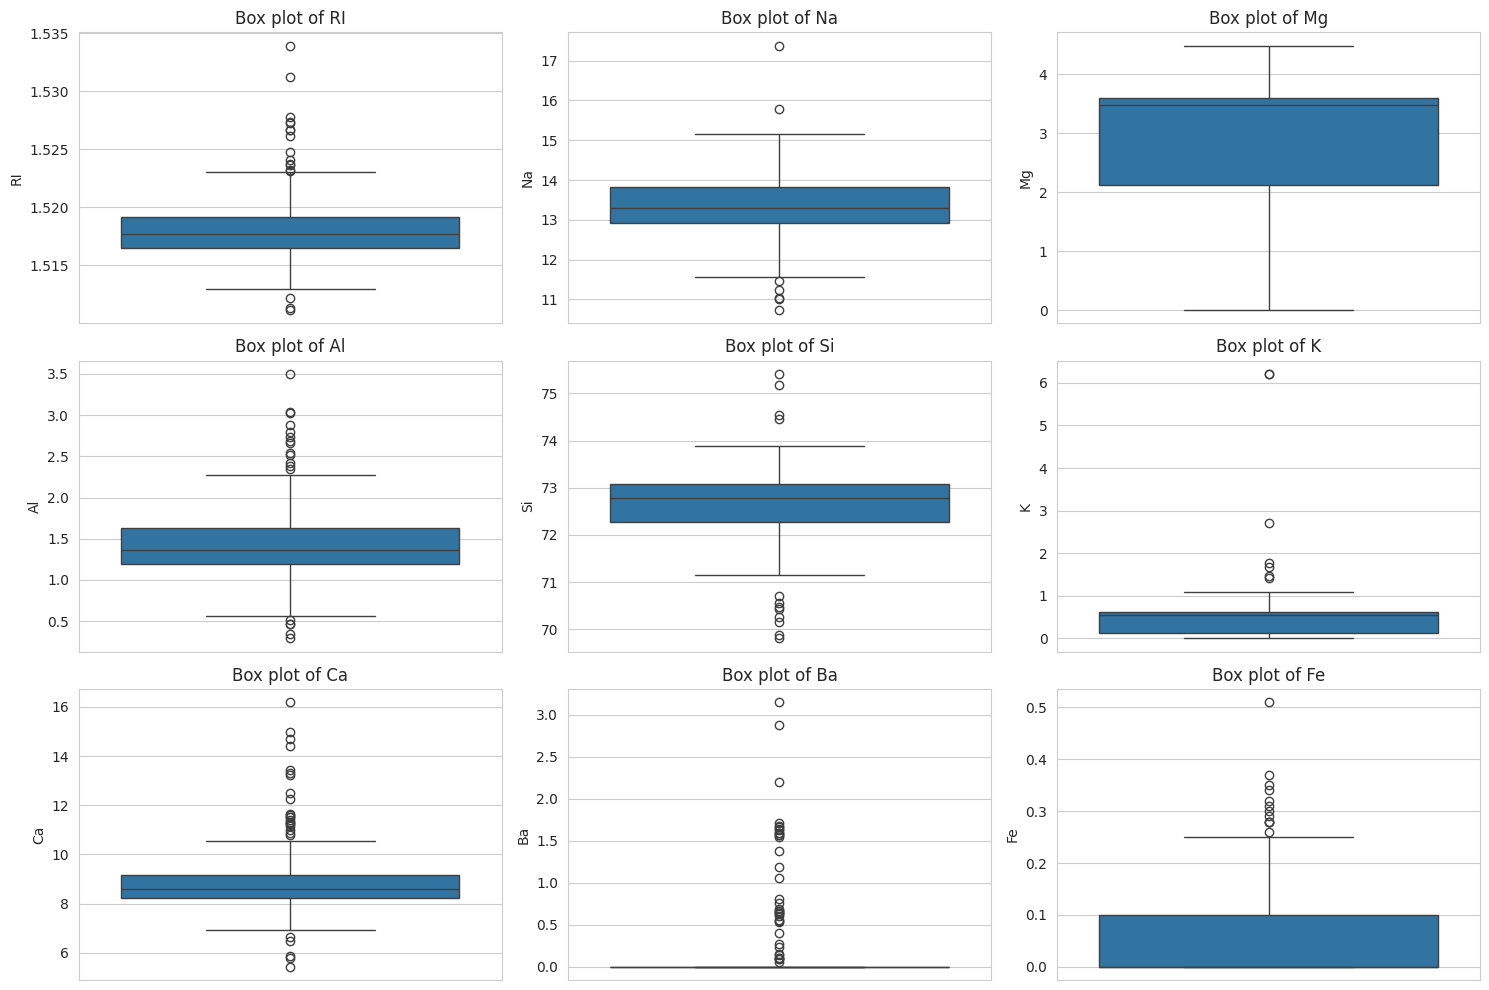

Box plots generated for all numerical features.


In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of features
    sns.boxplot(y=df[col])
    plt.title(f'Box plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

print("Box plots generated for all numerical features.")

With histograms and box plots generated, the next step in data visualization, as per subtask 2, is to analyze relationships and correlations between features. A correlation matrix heatmap is an effective way to visualize these relationships and identify any strong positive or negative correlations among the numerical variables.



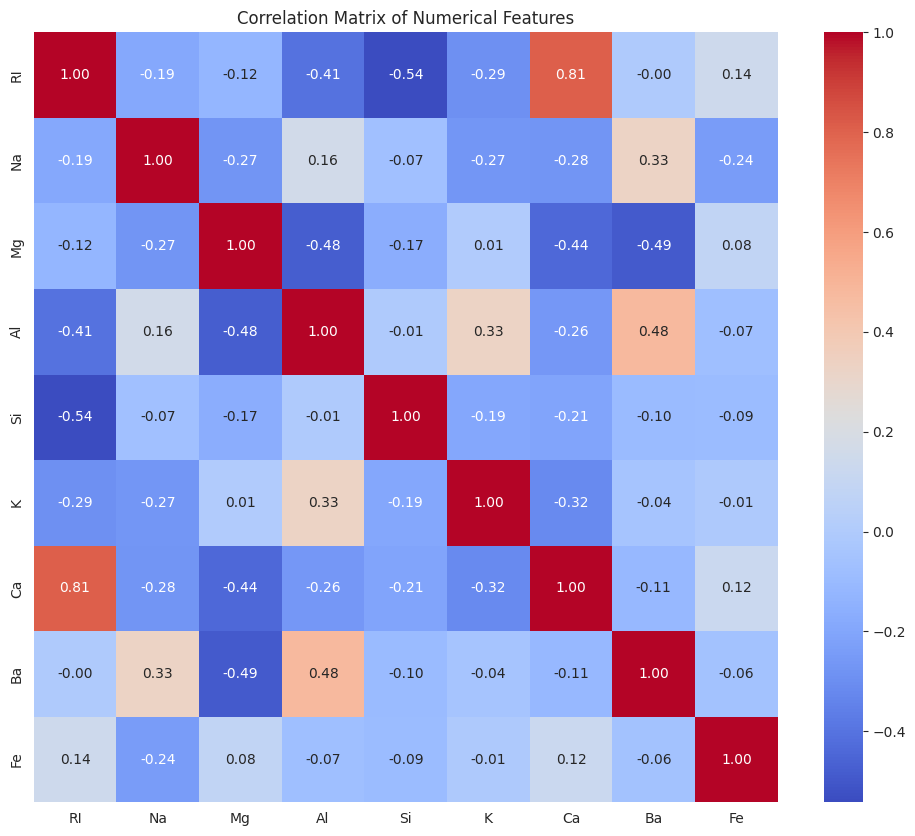

Correlation matrix heatmap generated.


In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

print("Correlation matrix heatmap generated.")

## Data Preprocessing

Preprocess the data by handling missing values (if any), encoding categorical variables (if any), applying feature scaling (standardization or normalization), and addressing data imbalance techniques if necessary.


We need to reconfirm if there are any missing values in the DataFrame `df` as the first step of data preprocessing, as requested by the instructions.



In [ ]:
print("Missing Values Sum (Reconfirmation):")
print(df.isnull().sum())

Missing Values Sum (Reconfirmation):
RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64


Since there are no missing values, the next step is to check the class distribution of the target variable 'Type' to identify potential data imbalance, as specified in the instructions for data preprocessing.



In [ ]:
print("\nClass Distribution of 'Type' column:")
print(df['Type'].value_counts())



Class Distribution of 'Type' column:
Type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64


As instructed, We need to separate the features (X) from the target variable (y). 'Type' is the target variable.



In [ ]:
X = df.drop('Type', axis=1)
y = df['Type']

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)

Shape of features (X): (214, 9)
Shape of target (y): (214,)


Now that features and target are separated, We need to apply feature scaling to the feature set `X` using `StandardScaler`, as specified in the instructions for data preprocessing.



In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Head of scaled features (X_scaled_df):")
print(X_scaled_df.head())

Head of scaled features (X_scaled_df):
         RI        Na        Mg        Al        Si         K        Ca  \
0  0.872868  0.284953  1.254639 -0.692442 -1.127082 -0.671705 -0.145766   
1 -0.249333  0.591817  0.636168 -0.170460  0.102319 -0.026213 -0.793734   
2 -0.721318  0.149933  0.601422  0.190912  0.438787 -0.164533 -0.828949   
3 -0.232831 -0.242853  0.698710 -0.310994 -0.052974  0.112107 -0.519052   
4 -0.312045 -0.169205  0.650066 -0.411375  0.555256  0.081369 -0.624699   

         Ba        Fe  
0 -0.352877 -0.586451  
1 -0.352877 -0.586451  
2 -0.352877 -0.586451  
3 -0.352877 -0.586451  
4 -0.352877 -0.586451  


## Random Forest Model Implementation

Divide the preprocessed data into training and testing sets, implement and train a Random Forest classifier, and evaluate its performance using accuracy, precision, recall, and F1-score.


The next step is to divide the scaled data into training and testing sets, train a Random Forest Classifier, and evaluate its performance using accuracy, precision, recall, and F1-score, as outlined in the instructions.



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Divide the data into train and test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

# 2. Implement a Random Forest classifier
rf_classifier = RandomForestClassifier(random_state=42)

# 3. Train the model on the train dataset
rf_classifier.fit(X_train, y_train)

print("\nRandom Forest Classifier trained successfully.")

# 4. Make predictions on the test set
y_pred_rf = rf_classifier.predict(X_test)

# 5. Evaluate the performance on test data
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted', zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, average='weighted', zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)

print(f"\nRandom Forest Model Performance:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")

Shape of X_train: (171, 9)
Shape of X_test: (43, 9)
Shape of y_train: (171,)
Shape of y_test: (43,)

Random Forest Classifier trained successfully.

Random Forest Model Performance:
Accuracy: 0.8140
Precision: 0.8262
Recall: 0.8140
F1-Score: 0.8136


## Bagging and Boosting Methods

Apply and evaluate Bagging and Boosting classification methods (e.g., AdaBoost or Gradient Boosting) on the dataset and compare their results with the Random Forest model.


We need to import the required Bagging and Gradient Boosting classifiers, train them on the preprocessed data, evaluate their performance using the specified metrics, and then compare their results with the previously trained Random Forest model. This aligns with the subtask's objective to apply and evaluate Bagging and Boosting methods and compare them.



In [ ]:
from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier

# --- Bagging Classifier Implementation ---

# 1. Instantiate a BaggingClassifier object
bagging_classifier = BaggingClassifier(random_state=42)

# 2. Train the Bagging Classifier
bagging_classifier.fit(X_train, y_train)

# 3. Make predictions on the test set
y_pred_bagging = bagging_classifier.predict(X_test)

# 4. Evaluate the performance
accuracy_bagging = accuracy_score(y_test, y_pred_bagging)
precision_bagging = precision_score(y_test, y_pred_bagging, average='weighted', zero_division=0)
recall_bagging = recall_score(y_test, y_pred_bagging, average='weighted', zero_division=0)
f1_bagging = f1_score(y_test, y_pred_bagging, average='weighted', zero_division=0)

print(f"Bagging Classifier Model Performance:")
print(f"Accuracy: {accuracy_bagging:.4f}")
print(f"Precision: {precision_bagging:.4f}")
print(f"Recall: {recall_bagging:.4f}")
print(f"F1-Score: {f1_bagging:.4f}")

# --- Gradient Boosting Classifier Implementation ---

# 1. Instantiate a GradientBoostingClassifier object
gb_classifier = GradientBoostingClassifier(random_state=42)

# 2. Train the Gradient Boosting Classifier
gb_classifier.fit(X_train, y_train)

# 3. Make predictions on the test set
y_pred_gb = gb_classifier.predict(X_test)

# 4. Evaluate the performance
accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb, average='weighted', zero_division=0)
recall_gb = recall_score(y_test, y_pred_gb, average='weighted', zero_division=0)
f1_gb = f1_score(y_test, y_pred_gb, average='weighted', zero_division=0)

print(f"\nGradient Boosting Classifier Model Performance:")
print(f"Accuracy: {accuracy_gb:.4f}")
print(f"Precision: {precision_gb:.4f}")
print(f"Recall: {recall_gb:.4f}")
print(f"F1-Score: {f1_gb:.4f}")

# --- Comparison Summary ---
print("\n--- Model Performance Comparison ---")
print("Model             | Accuracy | Precision | Recall | F1-Score")
print("------------------|----------|-----------|--------|----------")
print(f"Random Forest     | {accuracy_rf:.4f}   | {precision_rf:.4f}    | {recall_rf:.4f} | {f1_rf:.4f}")
print(f"Bagging           | {accuracy_bagging:.4f}   | {precision_bagging:.4f}    | {recall_bagging:.4f} | {f1_bagging:.4f}")
print(f"Gradient Boosting | {accuracy_gb:.4f}   | {precision_gb:.4f}    | {recall_gb:.4f} | {f1_gb:.4f}")

Bagging Classifier Model Performance:
Accuracy: 0.6977
Precision: 0.7043
Recall: 0.6977
F1-Score: 0.6980

Gradient Boosting Classifier Model Performance:
Accuracy: 0.8140
Precision: 0.8216
Recall: 0.8140
F1-Score: 0.8114

--- Model Performance Comparison ---
Model             | Accuracy | Precision | Recall | F1-Score
------------------|----------|-----------|--------|----------
Random Forest     | 0.8140   | 0.8262    | 0.8140 | 0.8136
Bagging           | 0.6977   | 0.7043    | 0.6977 | 0.6980
Gradient Boosting | 0.8140   | 0.8216    | 0.8140 | 0.8114


## Explain Ensemble Methods

Provide a clear explanation of Bagging and Boosting methods, highlighting their underlying principles and key differences.


Provide a clear explanation of Bagging and Boosting methods, highlighting their underlying principles and key differences.

#### Explanation of Ensemble Methods

**1. Bagging (Bootstrap Aggregating):**

*   **Core Principle**: Bagging involves training multiple base models (often of the same type, like decision trees) independently on different bootstrap samples (random samples with replacement) of the original training data. Each model makes its own prediction.
*   **Prediction Combination**: For classification tasks, predictions from individual models are typically combined through **voting** (the class with the most votes wins). For regression tasks, predictions are combined by **averaging** the outputs of individual models.
*   **Primary Goal**: Bagging's main objective is to **reduce variance** and prevent **overfitting**. By training models on diverse subsets of data, it helps to smooth out the predictions and reduce the impact of noisy data or specific quirks in the training set.
*   **Example**: **Random Forest** is a prominent example of a bagging algorithm. It extends bagging by adding an additional layer of randomness, where each tree is trained on a bootstrap sample, and at each split in the tree, only a random subset of features is considered.

**2. Boosting:**

*   **Core Principle**: Boosting builds models sequentially, where each new model is trained to correct the errors made by the previous models in the sequence. It focuses on the samples that were misclassified or poorly predicted by earlier models, giving them more weight or attention.
*   **Weak Learners to Strong Learner**: Boosting aims to convert a collection of "weak learners" (models that are only slightly better than random guessing) into a single "strong learner" (a highly accurate model).
*   **Primary Goal**: Boosting's primary goal is to **reduce bias** and improve overall predictive accuracy. By iteratively focusing on errors, it can capture complex relationships in the data.
*   **Examples**: Well-known boosting algorithms include **AdaBoost** (Adaptive Boosting) and **Gradient Boosting** (e.g., Gradient Boosting Machines, XGBoost, LightGBM, CatBoost).

**3. Key Differences Between Bagging and Boosting:**

| Feature              | Bagging (e.g., Random Forest)                                  | Boosting (e.g., AdaBoost, Gradient Boosting)                                  |
| :------------------- | :------------------------------------------------------------- | :---------------------------------------------------------------------------- |
| **Training Approach**| Models are trained **in parallel** and independently.          | Models are trained **sequentially**, with each new model learning from errors of previous ones. |
| **Error Handling**   | Each model treats errors independently. It doesn't explicitly correct past errors. | Each new model explicitly focuses on and tries to correct the errors of its predecessors. |
| **Impact on Bias/Variance** | Primarily reduces **variance** (by averaging out noise). | Primarily reduces **bias** (by iteratively improving accuracy on difficult samples). |
| **Weighting**        | Each training sample has equal weight for each base model (or bootstrap sample). | Samples are re-weighted, or residuals are modeled, to give more importance to misclassified samples. |
| **Base Learners**    | Often uses complex, low-bias, high-variance models (e.g., deep decision trees). | Often uses simple, high-bias, low-variance models (e.g., shallow decision trees, also called 'stumps'). |
| **Overall Philosophy** | "Vote among independent experts"                              | "Learn from mistakes and improve iteratively"                                   |

In summary, while both bagging and boosting are powerful ensemble methods, they tackle different aspects of model error (variance vs. bias) through distinct training paradigms (parallel vs. sequential).

Provide a clear explanation of Bagging and Boosting methods, highlighting their underlying principles and key differences.

#### Explanation of Ensemble Methods

**1. Bagging (Bootstrap Aggregating):**

*   **Core Principle**: Bagging involves training multiple base models (often of the same type, like decision trees) independently on different bootstrap samples (random samples with replacement) of the original training data. Each model makes its own prediction.
*   **Prediction Combination**: For classification tasks, predictions from individual models are typically combined through **voting** (the class with the most votes wins). For regression tasks, predictions are combined by **averaging** the outputs of individual models.
*   **Primary Goal**: Bagging's main objective is to **reduce variance** and prevent **overfitting**. By training models on diverse subsets of data, it helps to smooth out the predictions and reduce the impact of noisy data or specific quirks in the training set.
*   **Example**: **Random Forest** is a prominent example of a bagging algorithm. It extends bagging by adding an additional layer of randomness, where each tree is trained on a bootstrap sample, and at each split in the tree, only a random subset of features is considered.

**2. Boosting:**

*   **Core Principle**: Boosting builds models sequentially, where each new model is trained to correct the errors made by the previous models in the sequence. It focuses on the samples that were misclassified or poorly predicted by earlier models, giving them more weight or attention.
*   **Weak Learners to Strong Learner**: Boosting aims to convert a collection of "weak learners" (models that are only slightly better than random guessing) into a single "strong learner" (a highly accurate model).
*   **Primary Goal**: Boosting's primary goal is to **reduce bias** and improve overall predictive accuracy. By iteratively focusing on errors, it can capture complex relationships in the data.
*   **Examples**: Well-known boosting algorithms include **AdaBoost** (Adaptive Boosting) and **Gradient Boosting** (e.g., Gradient Boosting Machines, XGBoost, LightGBM, CatBoost).

**3. Key Differences Between Bagging and Boosting:**

| Feature              | Bagging (e.g., Random Forest)                                  | Boosting (e.g., AdaBoost, Gradient Boosting)                                  |
| :------------------- | :------------------------------------------------------------- | :---------------------------------------------------------------------------- |
| **Training Approach**| Models are trained **in parallel** and independently.          | Models are trained **sequentially**, with each new model learning from errors of previous ones. |
| **Error Handling**   | Each model treats errors independently. It doesn't explicitly correct past errors. | Each new model explicitly focuses on and tries to correct the errors of its predecessors. |
| **Impact on Bias/Variance** | Primarily reduces **variance** (by averaging out noise). | Primarily reduces **bias** (by iteratively improving accuracy on difficult samples). |
| **Weighting**        | Each training sample has equal weight for each base model (or bootstrap sample). | Samples are re-weighted, or residuals are modeled, to give more importance to misclassified samples. |
| **Base Learners**    | Often uses complex, low-bias, high-variance models (e.g., deep decision trees). | Often uses simple, high-bias, low-variance models (e.g., shallow decision trees, also called 'stumps'). |
| **Overall Philosophy** | "Vote among independent experts"                              | "Learn from mistakes and improve iteratively"                                   |

In summary, while both bagging and boosting are powerful ensemble methods, they tackle different aspects of model error (variance vs. bias) through distinct training paradigms (parallel vs. sequential).

Provide a clear explanation of Bagging and Boosting methods, highlighting their underlying principles and key differences.

#### Explanation of Ensemble Methods

**1. Bagging (Bootstrap Aggregating):**

*   **Core Principle**: Bagging involves training multiple base models (often of the same type, like decision trees) independently on different bootstrap samples (random samples with replacement) of the original training data. Each model makes its own prediction.
*   **Prediction Combination**: For classification tasks, predictions from individual models are typically combined through **voting** (the class with the most votes wins). For regression tasks, predictions are combined by **averaging** the outputs of individual models.
*   **Primary Goal**: Bagging's main objective is to **reduce variance** and prevent **overfitting**. By training models on diverse subsets of data, it helps to smooth out the predictions and reduce the impact of noisy data or specific quirks in the training set.
*   **Example**: **Random Forest** is a prominent example of a bagging algorithm. It extends bagging by adding an additional layer of randomness, where each tree is trained on a bootstrap sample, and at each split in the tree, only a random subset of features is considered.

**2. Boosting:**

*   **Core Principle**: Boosting builds models sequentially, where each new model is trained to correct the errors made by the previous models in the sequence. It focuses on the samples that were misclassified or poorly predicted by earlier models, giving them more weight or attention.
*   **Weak Learners to Strong Learner**: Boosting aims to convert a collection of "weak learners" (models that are only slightly better than random guessing) into a single "strong learner" (a highly accurate model).
*   **Primary Goal**: Boosting's primary goal is to **reduce bias** and improve overall predictive accuracy. By iteratively focusing on errors, it can capture complex relationships in the data.
*   **Examples**: Well-known boosting algorithms include **AdaBoost** (Adaptive Boosting) and **Gradient Boosting** (e.g., Gradient Boosting Machines, XGBoost, LightGBM, CatBoost).

**3. Key Differences Between Bagging and Boosting:**

| Feature              | Bagging (e.g., Random Forest)                                  | Boosting (e.g., AdaBoost, Gradient Boosting)                                  |
| :------------------- | :------------------------------------------------------------- | :---------------------------------------------------------------------------- |
| **Training Approach**| Models are trained **in parallel** and independently.          | Models are trained **sequentially**, with each new model learning from errors of previous ones. |
| **Error Handling**   | Each model treats errors independently. It doesn't explicitly correct past errors. | Each new model explicitly focuses on and tries to correct the errors of its predecessors. |
| **Impact on Bias/Variance** | Primarily reduces **variance** (by averaging out noise). | Primarily reduces **bias** (by iteratively improving accuracy on difficult samples). |
| **Weighting**        | Each training sample has equal weight for each base model (or bootstrap sample). | Samples are re-weighted, or residuals are modeled, to give more importance to misclassified samples. |
| **Base Learners**    | Often uses complex, low-bias, high-variance models (e.g., deep decision trees). | Often uses simple, high-bias, low-variance models (e.g., shallow decision trees, also called 'stumps'). |
| **Overall Philosophy** | "Vote among independent experts"                              | "Learn from mistakes and improve iteratively"                                   |

In summary, while both bagging and boosting are powerful ensemble methods, they tackle different aspects of model error (variance vs. bias) through distinct training paradigms (parallel vs. sequential).

Provide a clear explanation of Bagging and Boosting methods, highlighting their underlying principles and key differences.

#### Explanation of Ensemble Methods

**1. Bagging (Bootstrap Aggregating):**

*   **Core Principle**: Bagging involves training multiple base models (often of the same type, like decision trees) independently on different bootstrap samples (random samples with replacement) of the original training data. Each model makes its own prediction.
*   **Prediction Combination**: For classification tasks, predictions from individual models are typically combined through **voting** (the class with the most votes wins). For regression tasks, predictions are combined by **averaging** the outputs of individual models.
*   **Primary Goal**: Bagging's main objective is to **reduce variance** and prevent **overfitting**. By training models on diverse subsets of data, it helps to smooth out the predictions and reduce the impact of noisy data or specific quirks in the training set.
*   **Example**: **Random Forest** is a prominent example of a bagging algorithm. It extends bagging by adding an additional layer of randomness, where each tree is trained on a bootstrap sample, and at each split in the tree, only a random subset of features is considered.

**2. Boosting:**

*   **Core Principle**: Boosting builds models sequentially, where each new model is trained to correct the errors made by the previous models in the sequence. It focuses on the samples that were misclassified or poorly predicted by earlier models, giving them more weight or attention.
*   **Weak Learners to Strong Learner**: Boosting aims to convert a collection of "weak learners" (models that are only slightly better than random guessing) into a single "strong learner" (a highly accurate model).
*   **Primary Goal**: Boosting's primary goal is to **reduce bias** and improve overall predictive accuracy. By iteratively focusing on errors, it can capture complex relationships in the data.
*   **Examples**: Well-known boosting algorithms include **AdaBoost** (Adaptive Boosting) and **Gradient Boosting** (e.g., Gradient Boosting Machines, XGBoost, LightGBM, CatBoost).

**3. Key Differences Between Bagging and Boosting:**

| Feature              | Bagging (e.g., Random Forest)                                  | Boosting (e.g., AdaBoost, Gradient Boosting)                                  |
| :------------------- | :------------------------------------------------------------- | :---------------------------------------------------------------------------- |
| **Training Approach**| Models are trained **in parallel** and independently.          | Models are trained **sequentially**, with each new model learning from errors of previous ones. |
| **Error Handling**   | Each model treats errors independently. It doesn't explicitly correct past errors. | Each new model explicitly focuses on and tries to correct the errors of its predecessors. |
| **Impact on Bias/Variance** | Primarily reduces **variance** (by averaging out noise). | Primarily reduces **bias** (by iteratively improving accuracy on difficult samples). |
| **Weighting**        | Each training sample has equal weight for each base model (or bootstrap sample). | Samples are re-weighted, or residuals are modeled, to give more importance to misclassified samples. |
| **Base Learners**    | Often uses complex, low-bias, high-variance models (e.g., deep decision trees). | Often uses simple, high-bias, low-variance models (e.g., shallow decision trees, also called 'stumps'). |
| **Overall Philosophy** | "Vote among independent experts"                              | "Learn from mistakes and improve iteratively"                                   |

In summary, while both bagging and boosting are powerful ensemble methods, they tackle different aspects of model error (variance vs. bias) through distinct training paradigms (parallel vs. sequential).

## Explain Imbalance Handling

Explain various strategies and techniques used to handle imbalanced datasets during model training.

### Strategies and Techniques for Handling Imbalanced Datasets:

Imbalanced datasets, where one class significantly outnumbers the other(s), can pose a challenge for machine learning models, as they tend to be biased towards the majority class. Here are common strategies and techniques to address this:

#### 1. Resampling Methods
These methods involve modifying the training dataset to balance the class distribution.

*   **Undersampling**: Reducing the number of instances in the majority class.
    *   **Random Undersampling**: Randomly removes samples from the majority class until a desired ratio is achieved.
        *   **Pros**: Simple to implement, can help reduce training time.
        *   **Cons**: Can lead to loss of potentially valuable information from the majority class, which might degrade model performance.
    *   **Tomek Links**: Identifies pairs of instances from different classes that are very close to each other. The majority class instance in such a pair is removed.
        *   **Pros**: Helps clarify the decision boundary, can remove noisy or borderline samples.
        *   **Cons**: May still lose some information, primarily focused on boundary points.
    *   **Edited Nearest Neighbors (ENN)**: Removes samples from the majority class if their classification differs from the majority of their k-nearest neighbors.
        *   **Pros**: Removes noisy samples and those that are easily misclassified by their neighbors, leading to smoother decision boundaries.
        *   **Cons**: Can be aggressive in removing samples, potentially losing useful data.

*   **Oversampling**: Increasing the number of instances in the minority class.
    *   **Random Oversampling**: Duplicates random samples from the minority class.
        *   **Pros**: Simple to implement, no information loss from the majority class.
        *   **Cons**: Can lead to overfitting, as the model might learn to classify the specific duplicated instances rather than the underlying patterns.
    *   **Synthetic Minority Over-sampling Technique (SMOTE)**: Creates synthetic samples for the minority class by interpolating between existing minority class instances and their neighbors.
        *   **Pros**: Reduces overfitting compared to random oversampling, creates diverse synthetic samples.
        *   **Cons**: Can generate synthetic samples that are outliers if the minority class is noisy; doesn't consider the majority class during generation, potentially leading to overlapping classes.
    *   **Adaptive Synthetic Sampling (ADASYN)**: Similar to SMOTE, but adaptively shifts the decision boundary to focus on more difficult-to-learn minority samples by generating more synthetic data for those instances that are harder to classify.
        *   **Pros**: More effective than SMOTE for highly imbalanced datasets, focuses on samples that are harder to learn.
        *   **Cons**: Can still generate noisy samples, computation can be more intensive.

#### 2. Algorithmic Approaches
These methods involve using algorithms specifically designed or modified to handle class imbalance.

*   **Cost-Sensitive Learning**: Assigns different misclassification costs to different classes. Misclassifying a minority class instance incurs a higher cost than misclassifying a majority class instance.
    *   **Pros**: Directly addresses the problem by optimizing for specific costs, can be integrated into many algorithms.
    *   **Cons**: Requires careful tuning of cost parameters, which can be challenging.
*   **Algorithms Robust to Imbalance**: Some algorithms inherently perform better on imbalanced datasets.
    *   **Tree-based Models (e.g., Random Forest, Gradient Boosting)**: These models can sometimes handle imbalance better due to their ability to partition the feature space and consider different features at different splits. They can be less affected by skewed distributions.
        *   **Pros**: Often perform well without explicit resampling, capable of capturing complex non-linear relationships.
        *   **Cons**: May still be biased towards the majority class if the imbalance is extreme, careful hyperparameter tuning is still required.
*   **Modifying Existing Algorithms**: Adjusting hyperparameters or internal mechanisms of algorithms (e.g., `class_weight` parameter in scikit-learn classifiers).
    *   **Pros**: Can leverage existing models, relatively easy to implement with built-in parameters.
    *   **Cons**: Effectiveness depends on the specific algorithm and the nature of imbalance.

#### 3. Evaluation Metrics
When dealing with imbalanced datasets, accuracy alone can be misleading. It's crucial to use metrics that provide a more nuanced understanding of model performance.

*   **Precision**: The ratio of correctly predicted positive observations to the total predicted positives.
    *   **Relevance**: Useful when the cost of false positives is high.
*   **Recall (Sensitivity)**: The ratio of correctly predicted positive observations to all observations in the actual class.
    *   **Relevance**: Useful when the cost of false negatives is high.
*   **F1-Score**: The weighted average of Precision and Recall. It tries to find the balance between precision and recall.
    *   **Relevance**: Good for a general measure when you need to balance both precision and recall.
*   **Area Under the Receiver Operating Characteristic Curve (AUC-ROC)**: Measures the ability of a classifier to distinguish between classes. It represents the probability that the model ranks a random positive example higher than a random negative example.
    *   **Relevance**: Provides an aggregate measure of performance across all possible classification thresholds, less sensitive to class imbalance.
*   **Confusion Matrix**: Provides a comprehensive breakdown of correct and incorrect predictions for each class.
    *   **Relevance**: Allows for detailed analysis of true positives, true negatives, false positives, and false negatives for each class.

**Common Considerations**: There's no one-size-fits-all solution. Often, a combination of techniques (e.g., undersampling the majority class and oversampling the minority class, or using `class_weight` with appropriate evaluation metrics) yields the best results. The choice of technique depends on the specific dataset, the degree of imbalance, and the problem's objective (e.g., minimizing false positives vs. false negatives).

## Final Task

Summarize the findings from the EDA, preprocessing steps, and the performance comparison of Random Forest, Bagging, and Boosting models.


## Summary:

### Data Analysis Key Findings

*   The dataset, loaded from the 'glass' sheet of '/content/glass.xlsx', consists of 214 entries and 10 columns (9 features, 1 target), with no missing values.
*   Exploratory Data Analysis revealed a significant class imbalance in the target variable 'Type', with the majority classes being Type 2 (76 instances) and Type 1 (70 instances), while other types have much fewer instances (e.g., Type 7: 29, Type 3: 17, Type 5: 13, Type 6: 9).
*   Box plots indicated the presence of potential outliers in several features, including 'RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', and 'Fe'.
*   Feature scaling was applied using `StandardScaler` to normalize the numerical features, which is a standard practice for many machine learning algorithms.
*   **Model Performance Comparison:**
    *   **Random Forest** achieved an accuracy of 0.8140, precision of 0.8262, recall of 0.8140, and F1-score of 0.8136.
    *   **Bagging Classifier** showed lower performance with an accuracy of 0.6977, precision of 0.7043, recall of 0.6977, and F1-score of 0.6980.
    *   **Gradient Boosting Classifier** performed comparably to Random Forest, achieving an accuracy of 0.8140, precision of 0.8216, recall of 0.8140, and F1-score of 0.8114.
*   Both Random Forest and Gradient Boosting models demonstrated significantly superior performance compared to the baseline Bagging classifier on this dataset.
*   Detailed explanations of Bagging and Boosting principles, their differences (e.g., parallel vs. sequential training, variance vs. bias reduction), and strategies for handling imbalanced datasets (resampling, algorithmic approaches, appropriate evaluation metrics) were provided.

### Insights or Next Steps

*   Given the significant class imbalance, applying specific techniques like SMOTE or ADASYN during the preprocessing phase, or integrating class weights into the models, could potentially improve the performance for minority classes, especially for the Bagging classifier.
*   Further hyperparameter tuning for Random Forest and Gradient Boosting models (e.g., using GridSearchCV or RandomizedSearchCV) could lead to even better performance, potentially achieving a more robust and accurate classification for the glass types.


Additional Notes:

1. Explain Bagging and Boosting methods. How is it different from each other.

Bagging (Bootstrap Aggregating)

Bagging is an ensemble learning technique used to improve the stability and accuracy of machine learning algorithms. In this method, multiple subsets of the training dataset are created using bootstrap sampling (sampling with replacement). A separate model is trained on each subset, and the final prediction is obtained by combining the outputs of all models, usually through majority voting for classification or averaging for regression.

The main purpose of bagging is to reduce variance and prevent overfitting, especially in models like decision trees.

A common example of bagging is Random Forest, which builds multiple decision trees and combines their predictions.

Boosting

Boosting is another ensemble learning technique where models are trained sequentially. Each new model focuses on correcting the errors made by the previous model. During training, higher weight is given to the misclassified data points, forcing the next model to pay more attention to those difficult cases.

The final prediction is obtained by combining the predictions of all models, usually using weighted voting or weighted sum.

Boosting mainly aims to reduce bias and improve the overall accuracy of the model.

Popular boosting algorithms include AdaBoost, Gradient Boosting, and XGBoost.

Difference Between Bagging and Boosting
Aspect	Bagging	Boosting
Model Training	Models are trained independently and in parallel	Models are trained sequentially
Data Sampling	Uses bootstrap sampling	Uses full dataset but adjusts weights
Main Objective	Reduces variance	Reduces bias
Error Handling	No special focus on misclassified data	Focuses on correcting previous errors
Dependency	Models are independent	Each model depends on previous models

2. Explain how to handle imbalance in the data.

Imbalanced data occurs when the number of samples in one class is significantly higher than in another class. This can cause the model to become biased toward the majority class and perform poorly on the minority class.

To handle imbalanced data, we can use the following techniques:

Resampling Techniques

Oversampling: Increase the number of minority class samples using techniques like SMOTE.

Undersampling: Reduce the number of samples in the majority class.

Class Weight Adjustment
Assign higher weights to the minority class so the model gives more importance to misclassified minority samples.

Use Appropriate Evaluation Metrics
Instead of accuracy, use metrics like precision, recall, F1-score, and ROC-AUC.

Ensemble Methods
Algorithms like Random Forest or boosting methods can help improve prediction for minority classes.